In [9]:
import numpy as np
from matplotlib import pyplot as plt
import scipy

In [104]:
%run lib.ipynb

Exercise 1: Convergence Order Verification
For any ODE with a known exact solution (e.g. $y^{\prime}=-y, y(0)=1$, exact: $y=e^{-t}$ ), a method of order $p$ should satisfy $\left|y\left(t_f\right)-y_N\right| \propto h^p$.

(a) For the test problem $y^{\prime}=-y$ integrated to $t_f=1$, compute the global error for each of the following methods at $h=0.2,0.1,0.05,0.025,0.0125$ : forward Euler, backward Euler, explicit midpoint, Heun (predictor-corrector), implicit midpoint, RK4, AB2, AB4, AM1 (trapezoidal), BDF2 (How do you manage to start a multistep method?).

(b) Plot $\log _{10} \mid$ error $\mid$ vs. $\log _{10} h$ for all methods on the same graph. Measure the slopes by linear regression and compare with the theoretical orders.

(c) Identify any methods where the measured order deviates from the theoretical one and explain possible causes (startup errors for multistep methods, round-off at very small $h$, etc.).

In [34]:
def f_prime(t,y,args):
    return -y

In [35]:
integrate?

Signature: integrate(df_dt, t_range, IC, h, args=None, method=None)
Docstring: <no docstring>
File:      /tmp/ipykernel_60100/1072355963.py
Type:      function

In [86]:
h = 0.01
tf = 1

t_span = (0,tf)
y0 = [1]



In [87]:
tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
tei,yei = integrate(f_prime,t_span,y0,h,method=euler_implicit)
tme,yme = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)
tmi,ymi = integrate(f_prime,t_span,y0,h,method=midpoint_implicit)
tpc,ypc = integrate(f_prime,t_span,y0,h,method=predictor_corrector)

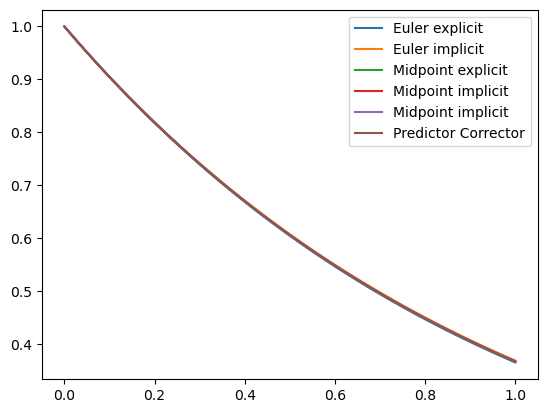

In [88]:
plt.plot(tee,yee[0], label='Euler explicit')
plt.plot(tei,yei[0], label='Euler implicit')
plt.plot(tme,yme[0], label='Midpoint explicit')
plt.plot(tmi,ymi[0], label='Midpoint implicit')
plt.plot(tmi,ymi[0], label='Midpoint implicit')
plt.plot(tpc,ypc[0], label='Predictor Corrector')

plt.legend()

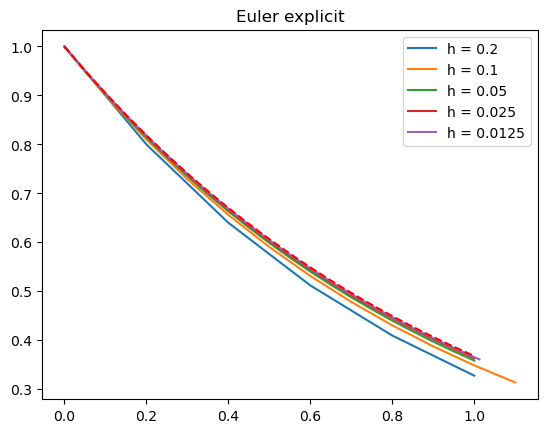

In [99]:
hs = [0.2,0.10,0.05,0.025,0.0125]
for h in hs:
    tee,yee = integrate(f_prime,t_span,y0,h,method=euler_explicit)
    plt.plot(tee,yee[0], label='h = '+str(h))
plt.legend()
plt.title('Euler explicit')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

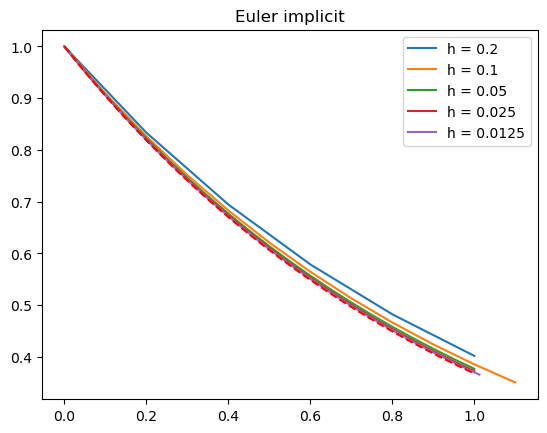

In [100]:
for h in hs:
    tei,yei = integrate(f_prime,t_span,y0,h,method=euler_implicit)
    plt.plot(tei,yei[0], label='h = '+str(h))
plt.legend()
plt.title('Euler implicit')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

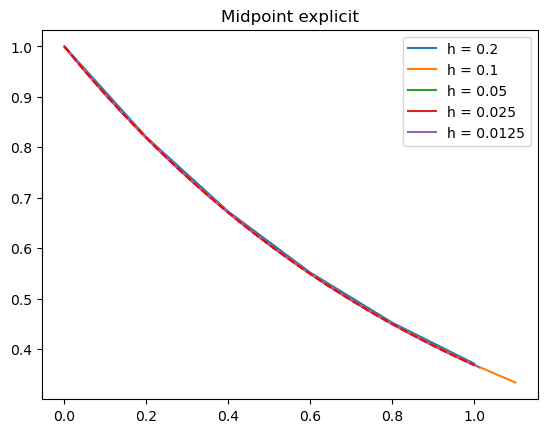

In [101]:
for h in hs:
    tme,yme = integrate(f_prime,t_span,y0,h,method=midpoint_explicit)
    plt.plot(tme,yme[0], label='h = '+str(h))
plt.legend()
plt.title('Midpoint explicit')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

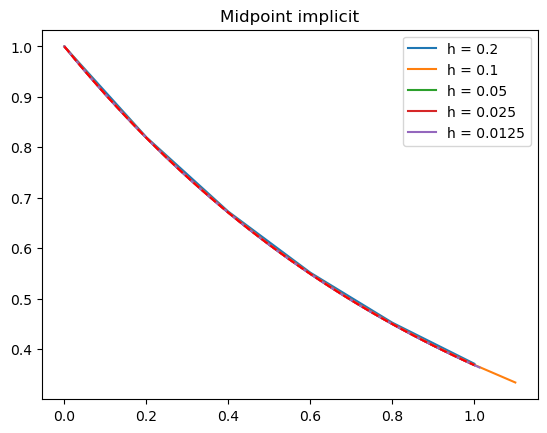

In [102]:
for h in hs:
    tmi,ymi = integrate(f_prime,t_span,y0,h,method=midpoint_implicit)
    plt.plot(tmi,ymi[0], label='h = '+str(h))
plt.legend()
plt.title('Midpoint implicit')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

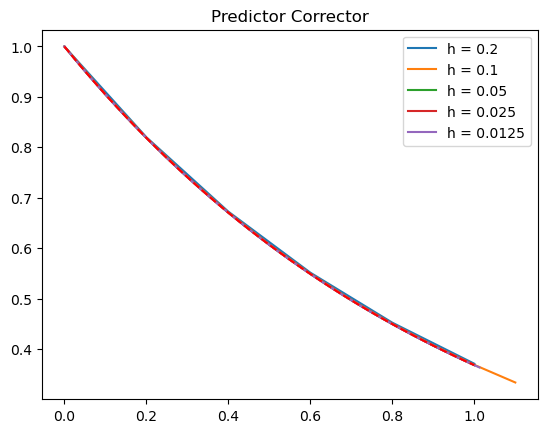

In [103]:
for h in hs:
    tpc,ypc = integrate(f_prime,t_span,y0,h,method=predictor_corrector)
    plt.plot(tpc,ypc[0], label='h = '+str(h))
plt.legend()
plt.title('Predictor Corrector')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

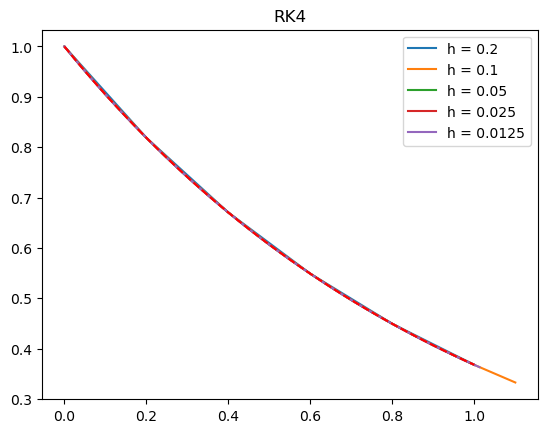

In [106]:
for h in hs:
    trk,yrk = integrate(f_prime,t_span,y0,h,method=RK4)
    plt.plot(trk,yrk[0], label='h = '+str(h))
plt.legend()
plt.title('RK4')
x=np.linspace(0,1)
plt.plot(x,np.exp(-x), linestyle='--',c='r')

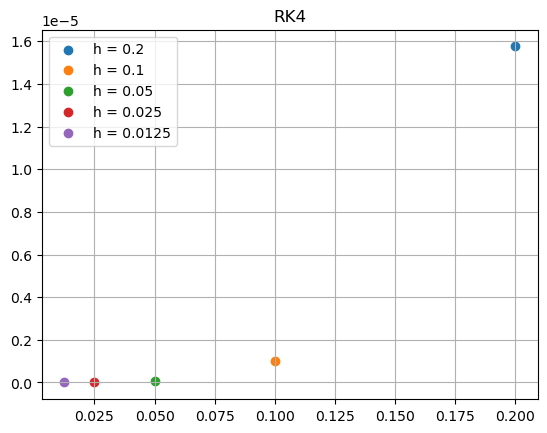

In [116]:
for h in hs:
    trk,yrk = integrate(f_prime,t_span,y0,h,method=RK4)
    plt.scatter(h,(yrk[0][-1]-np.exp(-trk[-1]))/np.exp(-trk[-1]), label='h = '+str(h))
plt.legend()
plt.title('RK4')
#plt.yscale('log')
plt.grid()